# Cuaderno De Análisis Exploratorio De Datos (EDA) Avanzado: Criptomonedas y Stablecoins

## Importación de librerías

In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import sys
from sqlalchemy import create_engine
from dotenv import load_dotenv
import numpy as np

## Configuración Entorno

In [44]:
warnings.filterwarnings('ignore')
sns.set_style("whitegrid")
plt.rcParams.update({'font.size': 11, 'axes.labelsize': 12, 'axes.titlesize': 14})

In [45]:
# 1. Cargar variables de entorno para la conexión segura
# (Ajusta la ruta de tu .env si es necesario; por ejemplo: '../.env')
load_dotenv(dotenv_path="../.env")  

DB_USER = os.getenv("DB_USER", "root")
DB_PASS = os.getenv("DB_PASS", "tu_password")
DB_HOST = os.getenv("DB_HOST", "localhost")
DB_NAME = os.getenv("DB_NAME", "criptoradar_db")

# 2. Establecer conexión con la base de datos MySQL
try:
    engine = create_engine(f"mysql+pymysql://{DB_USER}:{DB_PASS}@{DB_HOST}/{DB_NAME}")
    print("🔌 Conexión exitosa a MySQL.")
except Exception as e:
    print(f"❌ Error al conectar con la base de datos: {e}")
    sys.exit(1)

# 3. Cargar los datos desde la base de datos
print("📥 Cargando datos desde MySQL...")
try:
    df_crypto = pd.read_sql("SELECT * FROM Crypto_Precios", con=engine)
    df_stable = pd.read_sql("SELECT * FROM Preprocesados_Historico", con=engine)
    df_stablecoins_maestra = pd.read_sql("SELECT * FROM Stablecoins", con=engine)
    print("📥 Datos extraídos con éxito.")
except Exception as e:
    print(f"❌ Error al consultar las tablas: {e}")
    print("👉 Asegúrate de que las tablas ya han sido creadas y pobladas previamente.")
    sys.exit(1)


🔌 Conexión exitosa a MySQL.
📥 Cargando datos desde MySQL...
📥 Datos extraídos con éxito.


## Carga y Preprocesamiento de los Datasets

In [46]:
# print("=== Cargando datasets clean...")

# df_crypto = pd.read_csv("../data/clean/criptoradar_crypto_final_clean.csv")
# df_stable = pd.read_csv("../data/clean/datos_preprocesados_clean.csv")

# 1. Cargar tablas desde la base de datos
df_crypto = pd.read_sql("SELECT * FROM Crypto_Precios", con=engine)
df_stable_raw = pd.read_sql("SELECT * FROM Preprocesados_Historico", con=engine)
df_stablecoins_maestra = pd.read_sql("SELECT * FROM Stablecoins", con=engine)

# 2. Filtrar registros duplicados
df_crypto = df_crypto.drop_duplicates(subset=['crypto_id', 'datetime']).copy()
df_stable_raw = df_stable_raw.drop_duplicates(subset=['stablecoin_id', 'datetime']).copy()

# 3. Asegurar formato datetime para evitar problemas de tipos de datos
df_crypto['datetime'] = pd.to_datetime(df_crypto['datetime'])
df_stable_raw['datetime'] = pd.to_datetime(df_stable_raw['datetime'])

# 4. ACOPLAMIENTO CLAVE: Traer la columna de texto 'stablecoin' combinando con la maestra
df_stable = df_stable_raw.merge(df_stablecoins_maestra, on='stablecoin_id', how='left')
df_stable = df_stable.rename(columns={'nombre_stablecoin': 'stablecoin'})

# 5. Calcular la volatilidad diaria de criptos requerida para el primer gráfico
df_crypto['daily_volatility_pct'] = (df_crypto['high'] - df_crypto['low']) / df_crypto['open'] * 100

print(f"Dataset Cripto: {df_crypto.shape[0]} filas | Columnas: {list(df_crypto.columns)}")
print(f"Dataset Stablecoins: {df_stable.shape[0]} filas | Columnas: {list(df_stable.columns)}")

Dataset Cripto: 3216 filas | Columnas: ['datetime', 'crypto_id', 'open', 'high', 'low', 'close', 'volume', 'daily_volatility_pct']
Dataset Stablecoins: 30110 filas | Columnas: ['datetime', 'stablecoin_id', 'price', 'market_cap', 'peg_deviation', 'supply_change_1d', 'supply_change_7d', 'price_volatility_3d', 'stablecoin']


## Relación de fluctuación asimétrica y desviación como Anomalía


Distribución de Volatilidad vs Desviación del Peg...


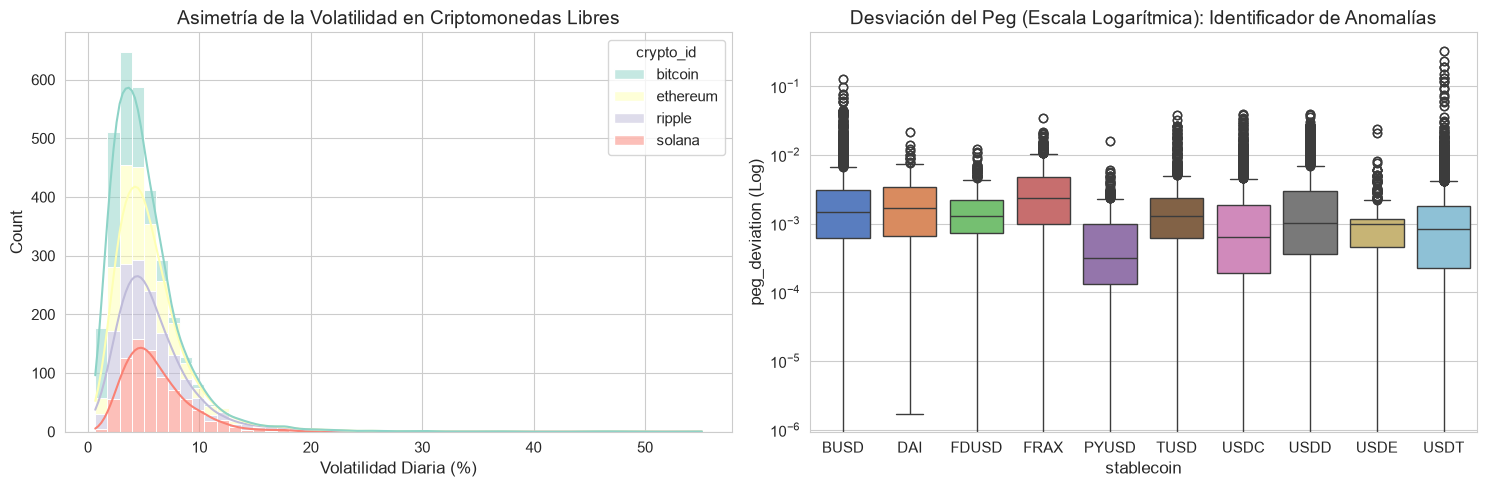

In [47]:
print("\nDistribución de Volatilidad vs Desviación del Peg...")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(data=df_crypto, x='daily_volatility_pct', hue='crypto_id', kde=True, ax=axes[0], bins=50, multiple="stack")
axes[0].set_title('Asimetría de la Volatilidad en Criptomonedas Libres')
axes[0].set_xlabel('Volatilidad Diaria (%)')

sns.boxplot(data=df_stable, x='stablecoin', y='peg_deviation', ax=axes[1], palette="muted")
axes[1].set_yscale('log')
axes[1].set_title('Desviación del Peg (Escala Logarítmica): Identificador de Anomalías')
axes[1].set_ylabel('peg_deviation (Log)')
plt.tight_layout()
plt.show()

## StableCoins Más/Menos Estables y Efecto del Market CAP


Análisis de Estabilidad y Tamaño de Suministro Circulante...

--- Tabla de Estabilidad Comparativa por Stablecoin ---
            desviacion_promedio  desviacion_maxima  volatilidad_prom_3d  market_cap_promedio
stablecoin                                                                                  
PYUSD                  0.000677           0.016000             0.000573         8.398887e+06
USDE                   0.001094           0.024000             0.000638         4.563422e+07
FDUSD                  0.001621           0.012359             0.001166         4.817393e+09
USDC                   0.001735           0.039867             0.001256         2.869839e+10
TUSD                   0.002034           0.038488             0.001270         6.793015e+08
DAI                    0.002296           0.021845             0.001867         5.240181e+09
USDT                   0.002352           0.328150             0.001764         6.494075e+10
USDD                   0.003124           0.

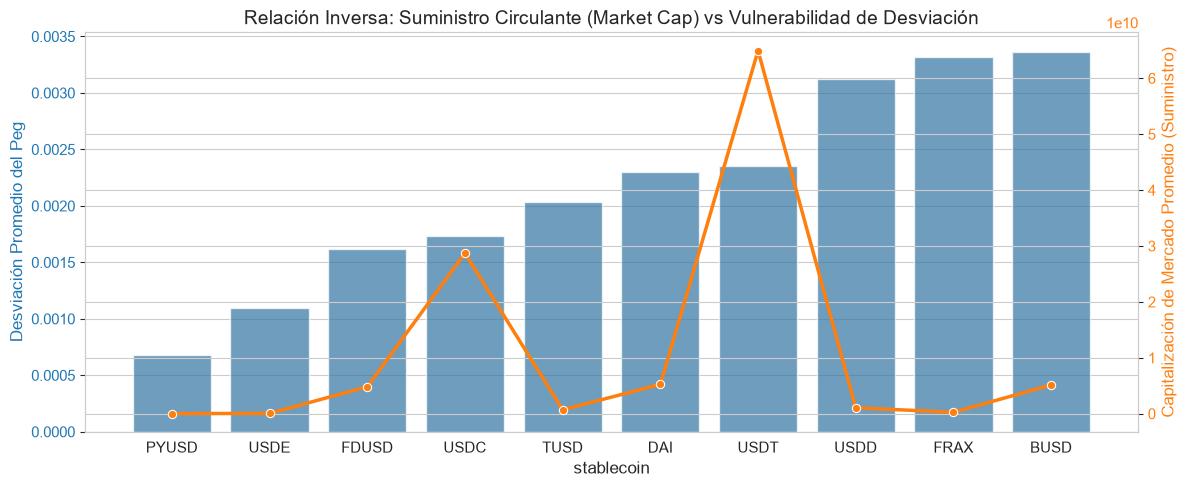

In [48]:
print("\nAnálisis de Estabilidad y Tamaño de Suministro Circulante...")

estabilidad_resumen = df_stable.groupby('stablecoin').agg(
    desviacion_promedio=('peg_deviation', 'mean'),
    desviacion_maxima=('peg_deviation', 'max'),
    volatilidad_prom_3d=('price_volatility_3d', 'mean'),
    market_cap_promedio=('market_cap', 'mean')
).sort_values(by='desviacion_promedio')

print("\n--- Tabla de Estabilidad Comparativa por Stablecoin ---")
print(estabilidad_resumen.to_string())

fig, ax1 = plt.subplots(figsize=(12, 5))
color = 'tab:blue'
sns.barplot(data=estabilidad_resumen.reset_index(), x='stablecoin', y='desviacion_promedio', ax=ax1, color=color, alpha=0.7)
ax1.set_ylabel('Desviación Promedio del Peg', color=color)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:orange'
sns.lineplot(data=estabilidad_resumen.reset_index(), x='stablecoin', y='market_cap_promedio', ax=ax2, color=color, marker='o', linewidth=2.5)
ax2.set_ylabel('Capitalización de Mercado Promedio (Suministro)', color=color)
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Relación Inversa: Suministro Circulante (Market Cap) vs Vulnerabilidad de Desviación')
plt.tight_layout()
plt.show()

## Correlación de precios Criptomonedas y el efecto de la liquidez (Volumen)


Correlación Cruzada y Efecto del Volumen sobre el Precio...


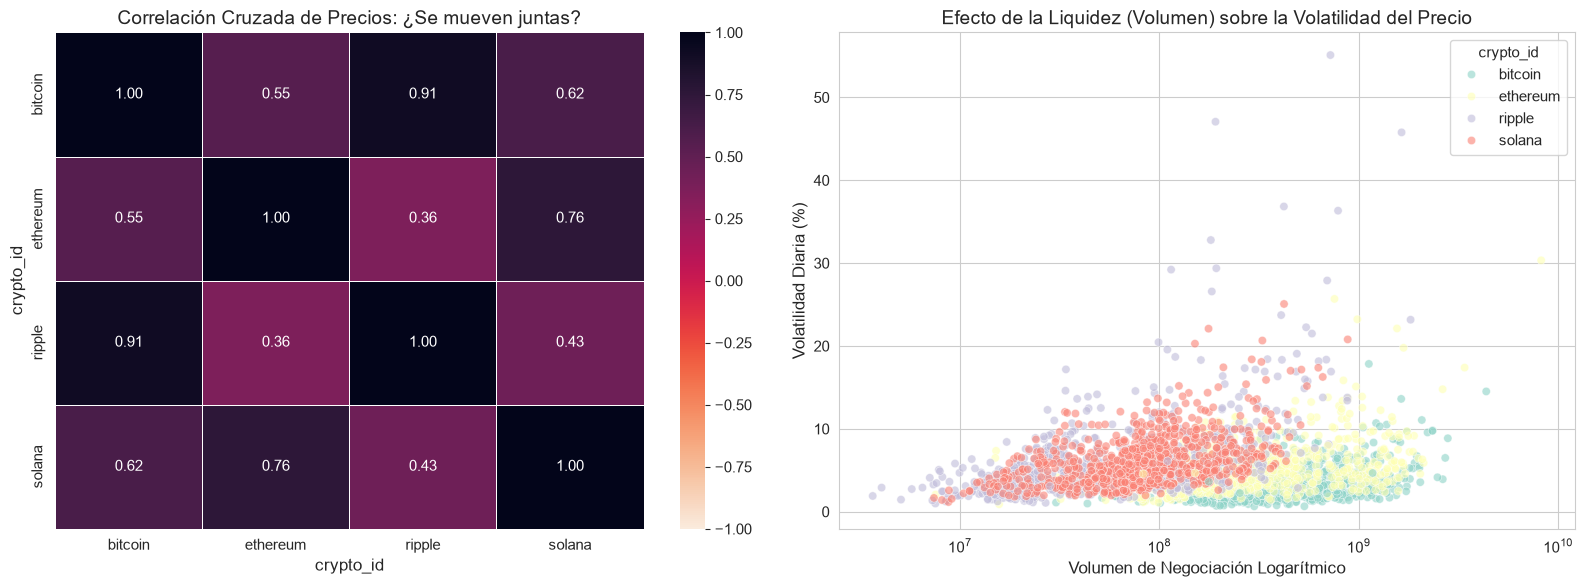

In [49]:
print("\nCorrelación Cruzada y Efecto del Volumen sobre el Precio...")

# Pivotar datos para matriz de correlación cruzada
df_pivot_prices = df_crypto.pivot(index='datetime', columns='crypto_id', values='close').dropna()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(df_pivot_prices.corr(method='pearson'), annot=True, cmap='rocket_r', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1, ax=axes[0])
axes[0].set_title('Correlación Cruzada de Precios: ¿Se mueven juntas?')

sns.scatterplot(data=df_crypto, x='volume', y='daily_volatility_pct', hue='crypto_id', alpha=0.6, ax=axes[1])
axes[1].set_xscale('log')
axes[1].set_title('Efecto de la Liquidez (Volumen) sobre la Volatilidad del Precio')
axes[1].set_xlabel('Volumen de Negociación Logarítmico')
axes[1].set_ylabel('Volatilidad Diaria (%)')
plt.tight_layout()
plt.show()

## Impacto de Bitcoin/Ethereum en las StableCoins (Análisis Cruzado)

**Nota importante antes de cruzar:** antes de mergear por fecha, primero comprobamos que
los periodos de ambos datasets realmente se solapen. Si no se solapan, un `inner merge`
devuelve 0 filas para esa moneda (no es un error de código, es un límite de los datos).


In [50]:
print("\nAnálisis de Interdependencia Temporal Cripto-Stablecoins...")

# Asegurar formato de fecha como texto para el cruce limpio
df_crypto['datetime_clean'] = pd.to_datetime(df_crypto['datetime']).dt.strftime('%Y-%m-%d')
df_stable['datetime_clean'] = pd.to_datetime(df_stable['datetime']).dt.strftime('%Y-%m-%d')

# Filtrar Bitcoin usando minúsculas para prevenir discrepancias ('bitcoin' o 'BTC')
df_btc = df_crypto[df_crypto['crypto_id'].astype(str).str.lower().isin(['bitcoin', 'btc'])][['datetime_clean', 'daily_volatility_pct', 'close']].rename(
    columns={'daily_volatility_pct': 'btc_volatility', 'close': 'btc_price'}
)

# Filtrar Ethereum usando ambos formatos habituales ('ethereum' o 'eth')
df_eth = df_crypto[df_crypto['crypto_id'].astype(str).str.lower().isin(['ethereum', 'eth'])][['datetime_clean', 'daily_volatility_pct', 'close']].rename(
    columns={'daily_volatility_pct': 'eth_volatility', 'close': 'eth_price'}
)

# Construcción del DataFrame unificado mediante Cruce Interno (Inner Merge)
df_cruzado = df_stable.merge(df_btc, on='datetime_clean', how='inner').merge(df_eth, on='datetime_clean', how='inner')

# Filtrar DAI eliminando espacios y forzando coincidencia exacta
df_cruzado['stablecoin'] = df_cruzado['stablecoin'].astype(str).str.strip().str.upper()
df_dai = df_cruzado[df_cruzado['stablecoin'] == 'DAI']

print(f"Filas Totales en df_cruzado: {df_cruzado.shape[0]}")
print(f"Filas específicas encontradas para DAI: {df_dai.shape[0]}")

# --- DIAGNÓSTICO: por qué puede quedar vacío df_dai (no es un problema de nombres/espacios) ---
# Comparamos el rango de fechas de DAI en bruto contra el rango de fechas del dataset cripto.
dai_raw = df_stable[df_stable['stablecoin'].astype(str).str.strip().str.upper() == 'DAI']
print(f"\nRango de fechas de DAI en el dataset de stablecoins: {dai_raw['datetime_clean'].min()} -> {dai_raw['datetime_clean'].max()} ({len(dai_raw)} filas)")
print(f"Rango de fechas del dataset de criptomonedas (BTC/ETH): {df_crypto['datetime_clean'].min()} -> {df_crypto['datetime_clean'].max()}")
print("\n(Si estos dos rangos no se solapan, el merge por fecha para DAI siempre dará 0 filas,")
print(" sin importar cómo se limpien nombres, espacios o mayúsculas)")



Análisis de Interdependencia Temporal Cripto-Stablecoins...
Filas Totales en df_cruzado: 12188
Filas específicas encontradas para DAI: 0

Rango de fechas de DAI en el dataset de stablecoins: 2020-12-03 -> 2022-05-11 (1000 filas)
Rango de fechas del dataset de criptomonedas (BTC/ETH): 2024-04-30 -> 2026-07-12

(Si estos dos rangos no se solapan, el merge por fecha para DAI siempre dará 0 filas,
 sin importar cómo se limpien nombres, espacios o mayúsculas)


❌ DAI no tiene NINGÚN día en común con el dataset de criptomonedas.
   DAI termina en 2022-05-11 y el dataset cripto empieza en 2024-04-30.
   Esto es una limitación de los datos, no un bug de nombres/formato: no existe forma de
   correlacionar la volatilidad de ETH con el peg de DAI sin ampliar alguno de los dos históricos.
   Como alternativa, mostramos abajo el comportamiento propio de DAI en su propio periodo disponible.


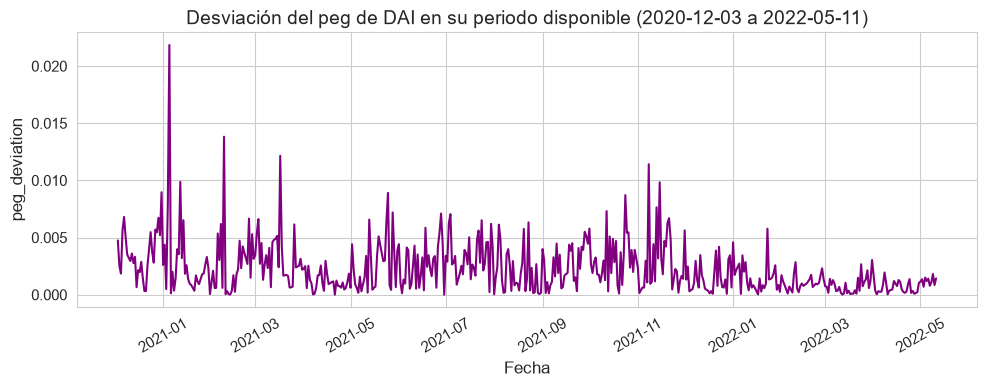

In [51]:
if df_dai.shape[0] == 0:
    # Confirmamos la causa real: ¿hay overlap de fechas entre DAI y el dataset cripto?
    solapan = (dai_raw['datetime_clean'].max() >= df_crypto['datetime_clean'].min()) and \
              (dai_raw['datetime_clean'].min() <= df_crypto['datetime_clean'].max())

    if not solapan:
        print("❌ DAI no tiene NINGÚN día en común con el dataset de criptomonedas.")
        print(f"   DAI termina en {dai_raw['datetime_clean'].max()} y el dataset cripto empieza en {df_crypto['datetime_clean'].min()}.")
        print("   Esto es una limitación de los datos, no un bug de nombres/formato: no existe forma de")
        print("   correlacionar la volatilidad de ETH con el peg de DAI sin ampliar alguno de los dos históricos.")
        print("   Como alternativa, mostramos abajo el comportamiento propio de DAI en su propio periodo disponible.")

        # --- Análisis alternativo autocontenido: volatilidad del peg de DAI en su propio periodo ---
        fig, ax = plt.subplots(figsize=(10, 4))
        dai_raw_sorted = dai_raw.sort_values('datetime_clean')
        ax.plot(pd.to_datetime(dai_raw_sorted['datetime_clean']), dai_raw_sorted['peg_deviation'], color='purple')
        ax.set_title(f"Desviación del peg de DAI en su periodo disponible ({dai_raw['datetime_clean'].min()} a {dai_raw['datetime_clean'].max()})")
        ax.set_xlabel('Fecha')
        ax.set_ylabel('peg_deviation')
        plt.xticks(rotation=30)
        plt.tight_layout()
        plt.show()
    else:
        # Si en el futuro los datos se actualizan y sí solapan pero sigue dando 0 filas,
        # entonces sí sería un problema de nombres/formato -> lo mostramos aquí
        print(f"⚠️ ALERTA: 'df_dai' sigue vacío pese a haber solape de fechas. Nombres disponibles en 'stablecoin': {df_cruzado['stablecoin'].unique()}")
else:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # Gráfico 1: Impacto del Bitcoin en el Mercado General de Stablecoins
    sns.regplot(data=df_cruzado, x='btc_volatility', y='peg_deviation',
                scatter_kws={'alpha':0.4, 'color':'gray'}, line_kws={'color':'red', 'linewidth':2}, ax=axes[0])
    axes[0].set_title('Impacto Global: Volatilidad de BTC vs Desviación de Stablecoins')
    axes[0].set_xlabel('Volatilidad Diaria de Bitcoin (%)')
    axes[0].set_ylabel('Desviación del Peg General')

    # Gráfico 2: Impacto del Colateral (Ethereum) sobre DAI
    sns.regplot(data=df_dai, x='eth_volatility', y='peg_deviation',
                scatter_kws={'alpha':0.6, 'color':'purple'}, line_kws={'color':'darkblue', 'linewidth':2}, ax=axes[1])
    axes[1].set_title('Relación Estructural Directa: Volatilidad de ETH vs Peg de DAI')
    axes[1].set_xlabel('Volatilidad Diaria de Ethereum (%)')
    axes[1].set_ylabel('Desviación del Peg (DAI)')

    plt.tight_layout()
    plt.show()


In [52]:
# NOTA: df_cruzado no incluye a DAI (no comparte fechas con el dataset cripto),
# por lo que esta matriz refleja únicamente las 9 stablecoins restantes.
# Mostrar matriz de correlaciones numéricas del dataset unificado
print("\n--- Matriz de Correlación Cruzada entre Estructuras de Mercado ---")
columnas_interes = ['peg_deviation', 'price_volatility_3d', 'market_cap', 'btc_volatility', 'eth_volatility']
print(df_cruzado[columnas_interes].corr().round(3))


--- Matriz de Correlación Cruzada entre Estructuras de Mercado ---
                     peg_deviation  price_volatility_3d  market_cap  \
peg_deviation                1.000                0.595      -0.159   
price_volatility_3d          0.595                1.000      -0.129   
market_cap                  -0.159               -0.129       1.000   
btc_volatility               0.032                0.004      -0.011   
eth_volatility               0.018                0.011      -0.003   

                     btc_volatility  eth_volatility  
peg_deviation                 0.032           0.018  
price_volatility_3d           0.004           0.011  
market_cap                   -0.011          -0.003  
btc_volatility                1.000           0.741  
eth_volatility                0.741           1.000  


## Lista de estable_coins para Analizar 

In [53]:
#Definición estricta de la función mapeando las monedas que existen en tus archivos CSV
def clasificar_respaldo_real(coin):
    if coin in ['USDT', 'USDC', 'BUSD', 'PYUSD', 'TUSD', 'FDUSD']:
        return 'Fiat-Backed'
    elif coin in ['DAI']:
        return 'Crypto-Backed'
    elif coin in ['FRAX']:
        return 'Fractional-Algorithmic'
    elif coin in ['USDD']:
        return 'Algorithmic'
    elif coin in ['USDE']:
        return 'Arbitraje de Derivados / Cripto'
    else:
        return 'No Clasificado'

In [54]:
# 2. Creamos la columna en df_stable asegurando que el mapeo ocurra inmediatamente antes del groupby
df_stable['tipo_respaldo'] = df_stable['stablecoin'].apply(clasificar_respaldo_real)

## Calculo de Matriz de Correlación de Capitalizaciones (Market Cap)

In [55]:
# 1. Asegurar formato de fecha uniforme
df_stable['datetime'] = pd.to_datetime(df_stable['datetime'])

# 2. ELIMINAR DUPLICADOS: Nos quedamos únicamente con el primer registro de cada combinación (datetime, stablecoin)
df_stable_clean = df_stable.drop_duplicates(subset=['datetime', 'stablecoin'], keep='first')

# 3. Construcción de la matriz temporal para las capitalizaciones (Market Cap) de forma segura
df_pivot_cap = df_stable_clean.pivot(index='datetime', columns='stablecoin', values='market_cap')

# 4. Calcular la matriz de correlación
matriz_corr_cap = df_pivot_cap.corr()

In [56]:
# Impresión de métricas exactas calculadas desde el csv
corr_pyusd_usdc = matriz_corr_cap.loc['PYUSD', 'USDC']
corr_usdc_usdt = matriz_corr_cap.loc['USDC', 'USDT']

In [57]:
print("=== 1. RELACIÓN DE MOVIMIENTOS (CAPITALIZACIÓN) ===")
print(f"• Correlación empírica real entre PYUSD y USDC: {corr_pyusd_usdc:.4f}")
print(f"• Correlación empírica real entre USDC y USDT: {corr_usdc_usdt:.4f}\n")

=== 1. RELACIÓN DE MOVIMIENTOS (CAPITALIZACIÓN) ===
• Correlación empírica real entre PYUSD y USDC: -0.8023
• Correlación empírica real entre USDC y USDT: 0.9290



## Ranking Real de Inestabilidad (Peg Deviation Promedio)

In [58]:
ranking_inestabilidad = df_stable.groupby('stablecoin')['peg_deviation'].agg(['mean', 'std', 'max', 'count']).sort_values(by='mean', ascending=False)

print("=== 2. ¿QUÉ STABLECOINS SON LAS MÁS INESTABLES SEGÚN TUS DATOS? ===")
print(ranking_inestabilidad.to_string(), "\n")

=== 2. ¿QUÉ STABLECOINS SON LAS MÁS INESTABLES SEGÚN TUS DATOS? ===
                mean       std       max  count
stablecoin                                     
BUSD        0.003367  0.007281  0.127613   4140
FRAX        0.003319  0.003194  0.034422   3320
USDD        0.003124  0.005252  0.038681   2680
USDT        0.002352  0.011336  0.328150   5700
DAI         0.002296  0.002260  0.021845   1000
TUSD        0.002034  0.003019  0.038488   3440
USDC        0.001735  0.003341  0.039867   4946
FDUSD       0.001621  0.001417  0.012359   1716
USDE        0.001094  0.001475  0.024000   1500
PYUSD       0.000677  0.000997  0.016000   1668 



## Comparativa por tipo de respaldo real

In [59]:
analisis_respaldo = df_stable.groupby('tipo_respaldo')['peg_deviation'].agg(['mean', 'std', 'max', 'count']).sort_values(by='mean', ascending=False)

print("=== 3. IMPACTO REAL: ¿TIPO DE RESPALDO VS NIVEL DE CONFIANZA? ===")
print(analisis_respaldo.to_string())

=== 3. IMPACTO REAL: ¿TIPO DE RESPALDO VS NIVEL DE CONFIANZA? ===
                                     mean       std       max  count
tipo_respaldo                                                       
Fractional-Algorithmic           0.003319  0.003194  0.034422   3320
Algorithmic                      0.003124  0.005252  0.038681   2680
Crypto-Backed                    0.002296  0.002260  0.021845   1000
Fiat-Backed                      0.002167  0.006987  0.328150  21610
Arbitraje de Derivados / Cripto  0.001094  0.001475  0.024000   1500


## Generación de gráficos complentarios para el EDA

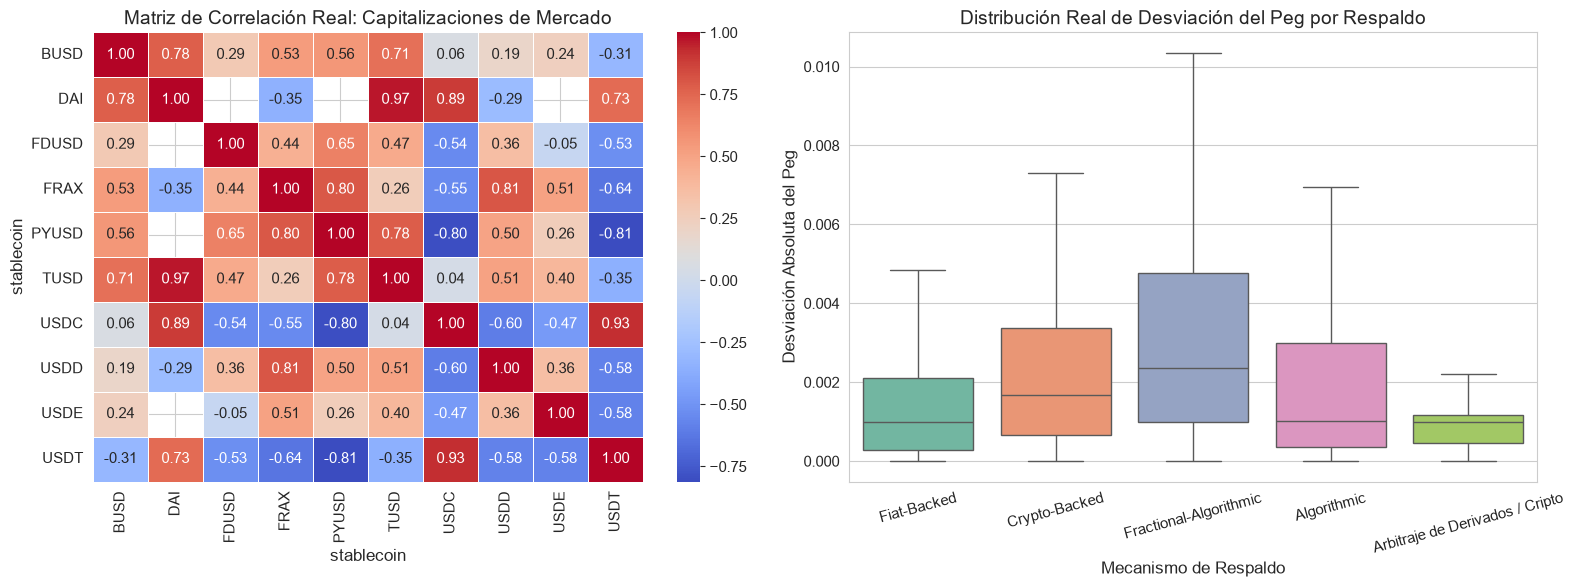

In [60]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico izquierdo: El mapa de calor real de las dependencias de capitalización
sns.heatmap(matriz_corr_cap, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, ax=axes[0])
axes[0].set_title('Matriz de Correlación Real: Capitalizaciones de Mercado')

# Gráfico derecho: Distribución real libre de outliers para ver el comportamiento del día a día
sns.boxplot(data=df_stable, x='tipo_respaldo', y='peg_deviation', showfliers=False, palette='Set2', ax=axes[1])
axes[1].set_title('Distribución Real de Desviación del Peg por Respaldo')
axes[1].set_xlabel('Mecanismo de Respaldo')
axes[1].set_ylabel('Desviación Absoluta del Peg')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=15)

plt.tight_layout()
plt.show()

## Desviación de fecha respecto establecoin y criptomoneda

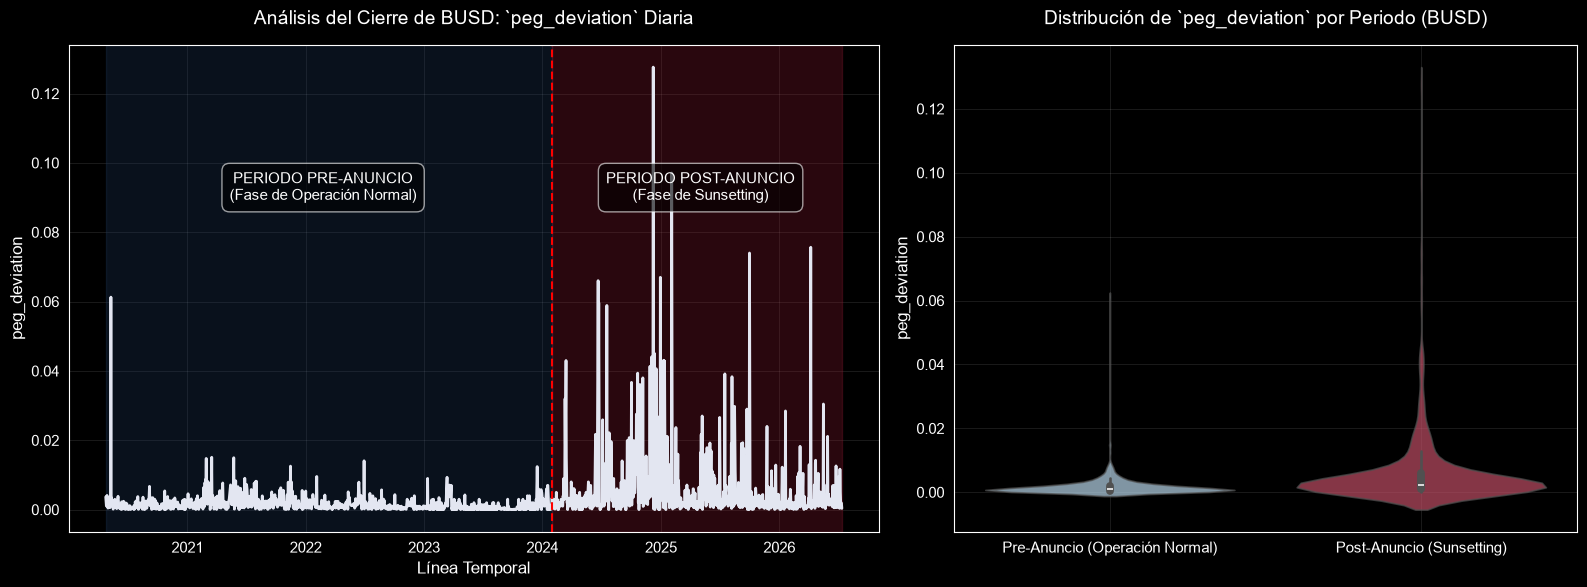

In [61]:
# 1. Configurar estilo visual oscuro
plt.style.use('dark_background')
fig, axes = plt.subplots(1, 2, figsize=(16, 6), gridspec_kw={'width_ratios': [1.3, 1]})

# 2. Cargar los datos directamente desde tu archivo CSV
# CAMBIA ESTA RUTA por la de tu archivo (por ejemplo: 'data/historico_stablecoins.csv')
df_global = pd.read_csv("../data/clean/datos_preprocesados_clean.csv")

# Filtrar para quedarnos únicamente con BUSD
df_busd = df_global[df_global['stablecoin'] == 'BUSD'].copy()

# Convertir la columna de fecha a formato datetime y ordenar
df_busd['datetime'] = pd.to_datetime(df_busd['datetime'])
df_busd = df_busd.sort_values('datetime')

# 3. Definir el hito del evento (Febrero 2024) y partir el dataset
fecha_evento = pd.to_datetime('2024-02-01')

df_busd['periodo'] = np.where(
    df_busd['datetime'] < fecha_evento, 
    'Pre-Anuncio (Operación Normal)', 
    'Post-Anuncio (Sunsetting)'
)

# =====================================================================
# PANEL 1: SERIE TEMPORAL DIVIDIDA (Eje izquierdo)
# =====================================================================
ax1 = axes[0]
ax1.plot(df_busd['datetime'], df_busd['peg_deviation'], color="#e3e6f1", linewidth=2, label='peg_deviation')

# Colorear los fondos de los periodos
df_pre = df_busd[df_busd['datetime'] < fecha_evento]
ax1.axvspan(df_pre['datetime'].min(), fecha_evento, color='#1f3a60', alpha=0.3, label='Fase Operación Normal')

df_post = df_busd[df_busd['datetime'] >= fecha_evento]
ax1.axvspan(fecha_evento, df_post['datetime'].max(), color='#8b1a2f', alpha=0.3, label='Fase Sunsetting')

# Línea divisoria del evento
ax1.axvline(fecha_evento, color='red', linestyle='--', linewidth=1.5)

# Detalles estéticos del Panel 1
ax1.set_title('Análisis del Cierre de BUSD: `peg_deviation` Diaria', fontsize=14, pad=15)
ax1.set_ylabel('peg_deviation', fontsize=12)
ax1.set_xlabel('Línea Temporal', fontsize=12)
ax1.grid(True, alpha=0.1)

# Textos explicativos dentro del gráfico
ax1.text(df_pre['datetime'].mean(), df_busd['peg_deviation'].max()*0.7, 'PERIODO PRE-ANUNCIO\n(Fase de Operación Normal)', 
         color='white', ha='center', bbox=dict(facecolor='black', alpha=0.6, boxstyle='round,pad=0.5'))
ax1.text(df_post['datetime'].mean(), df_busd['peg_deviation'].max()*0.7, 'PERIODO POST-ANUNCIO\n(Fase de Sunsetting)', 
         color='white', ha='center', bbox=dict(facecolor='black', alpha=0.6, boxstyle='round,pad=0.5'))

# =====================================================================
# PANEL 2: COMPARATIVA DE DISTRIBUCIÓN (Eje derecho)
# =====================================================================
ax2 = axes[1]
colores_periodos = {'Pre-Anuncio (Operación Normal)': '#aed8f2', 'Post-Anuncio (Sunsetting)': '#d13b5a'}

sns.violinplot(
    data=df_busd, 
    x='periodo', 
    y='peg_deviation', 
    ax=ax2, 
    palette=colores_periodos, 
    inner='box',
    alpha=0.7
)

ax2.set_title('Distribución de `peg_deviation` por Periodo (BUSD)', fontsize=14, pad=15)
ax2.set_ylabel('peg_deviation', fontsize=12)
ax2.set_xlabel('', fontsize=12)
ax2.grid(True, alpha=0.1)

plt.tight_layout()
plt.show()

## Comportamiento Stablecoin BUSD
La stablecoin descontinuada (BUSD) se comporta distinto antes/después de que Binance anunciara el cierreLa stablecoin descontinuada (BUSD) se comporta distinto antes/después de que Binance anunciara el cierre.

BUSD mostró un comportamiento estadísticamente distinto tras el anuncio del cierre, pasando de una estabilidad casi perfecta a un periodo de decrecimiento forzado donde su paridad experimentó pequeñas pero frecuentes desviaciones a la baja y volatilidad, concluyendo con una contracción masiva de capital hasta su descontinuación.

In [64]:
df_bitcoin = df_crypto[df_crypto['crypto_id'] == 'bitcoin'].copy()

# 2. Combinamos los datos por fecha (ahora sí, 1 única fila de cripto por día)
df_estudio = pd.merge(df_stable, df_bitcoin, on='datetime', how='inner')

# 3. Creamos las variables con retardo (Shift de 1 día hacia el futuro)
# Agrupamos por 'stablecoin' en AMBOS para que el cambio de moneda no ensucie los datos
df_estudio['peg_deviation_mañana'] = df_estudio.groupby('stablecoin')['peg_deviation'].shift(-1)
df_estudio['btc_volatility_mañana'] = df_estudio.groupby('stablecoin')['daily_volatility_pct'].shift(-1)

# 4. Calculamos las correlaciones cruzadas temporales
corr_cripto_a_stable = df_estudio['daily_volatility_pct'].corr(df_estudio['peg_deviation_mañana'])
corr_stable_a_cripto = df_estudio['peg_deviation'].corr(df_estudio['btc_volatility_mañana'])

print("📊 --- CORRELACIONES DE BITCOIN FILTRADO ---")
print(f"Impacto Cripto -> Stable (¿Volatilidad BTC hoy predice depeg mañana?): {corr_cripto_a_stable:.4f}")
print(f"Impacto Stable -> Cripto (¿Depeg hoy predice volatilidad BTC mañana?): {corr_stable_a_cripto:.4f}")

📊 --- CORRELACIONES DE BITCOIN FILTRADO ---
Impacto Cripto -> Stable (¿Volatilidad BTC hoy predice depeg mañana?): 0.0301
Impacto Stable -> Cripto (¿Depeg hoy predice volatilidad BTC mañana?): 0.0222
